# Tigges 2024 IOI replication — Pythia-410M

**Phase 1.2 methodological gate.** Reproduce the IOI accuracy curve across Pythia-410M training checkpoints reported in Tigges et al. (NeurIPS 2024) / `curt-tigges/circuits-over-time`. If our pipeline matches the published curve within tolerance, the rest of the project inherits that calibration.

**Locked design (NOTES.md 2026-05-05):**
- Prompts: `data/prompts/ioi_prompts.tsv` (Wang 2023 single-clause BABA/ABBA template; N=200, seed=0; GPT-NeoX single-token names only)
- Model: `EleutherAI/pythia-410m-deduped` (Tigges used `-no-dropout`; this is our pipeline default — flagged for the gate verdict)
- Checkpoints: `{0, 1000, 3000, 8000, 25000, 50000, 100000, 143000}`
- Metrics: accuracy (gate metric per the brief) + mean logit-diff (supplementary)
- Gate: per-checkpoint absolute-difference `< 0.10` against Tigges' published values. Tigges reports `{1000, 10000, 50000, 100000, 143000}`; our checkpoint grid intersects at `{1000, 50000, 100000, 143000}` (we run step8000 instead of step10000 to share grid points with the copy-suppression sweep). The gate compares at those 4 shared steps. The full 8-checkpoint accuracy curve is plotted alongside Tigges' 5 values for shape comparison.

**Tigges reference values** (from `circuits-over-time/results/task_performance_metrics/pythia-410m-no-dropout/metrics.pt`):

| step    | Tigges IOI accuracy |
|---------|---------------------|
| 1000    | 0.4286              |
| 10000   | 0.9714              |
| 50000   | 1.0000              |
| 100000  | 1.0000              |
| 143000  | 1.0000              |

**Divergences from Tigges to keep in mind:**
1. We use N=200 prompts; Tigges used N=70 (their accuracy values are fractions of 70: 30/70=0.4286, 68/70=0.9714).
2. We use Pythia-410M-deduped; Tigges used Pythia-410M-no-dropout. Whether this materially shifts the curve is itself a finding.

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load aggregate metrics

In [2]:
agg = pd.read_parquet(REPO / 'data' / 'exploration' / 'tigges_ioi_replication.parquet')
print(agg.to_string(index=False))

size   step          metric     value  n_prompts
410m      0        accuracy  0.470000        200
410m      0 mean_logit_diff -0.019990        200
410m   1000        accuracy  0.495000        200
410m   1000 mean_logit_diff -0.205339        200
410m   3000        accuracy  0.590000        200
410m   3000 mean_logit_diff  0.475815        200
410m   8000        accuracy  0.920000        200
410m   8000 mean_logit_diff  2.100111        200
410m  25000        accuracy  0.995000        200
410m  25000 mean_logit_diff  2.611685        200
410m  50000        accuracy  0.995000        200
410m  50000 mean_logit_diff  2.802343        200
410m 100000        accuracy  0.995000        200
410m 100000 mean_logit_diff  3.073618        200
410m 143000        accuracy  0.990000        200
410m 143000 mean_logit_diff  2.921241        200


## Tigges reference values

From `circuits-over-time` repo's `metrics.pt`. Step10000 is included for the curve plot even though our run uses step8000 — they bracket the emergence knee.

In [3]:
TIGGES_REFERENCE = {
    1000:   0.4286,
    10000:  0.9714,
    50000:  1.0000,
    100000: 1.0000,
    143000: 1.0000,
}
GATE_TOLERANCE = 0.10  # locked in NOTES.md Phase 1.2 grilling Q6

## Accuracy curve — ours vs Tigges

Our 8 checkpoints in blue; Tigges' 5 published values in red. The gate compares the four directly-shared steps: 1000, 50000, 100000, 143000. Step10000 is plotted but not directly comparable to our step8000.

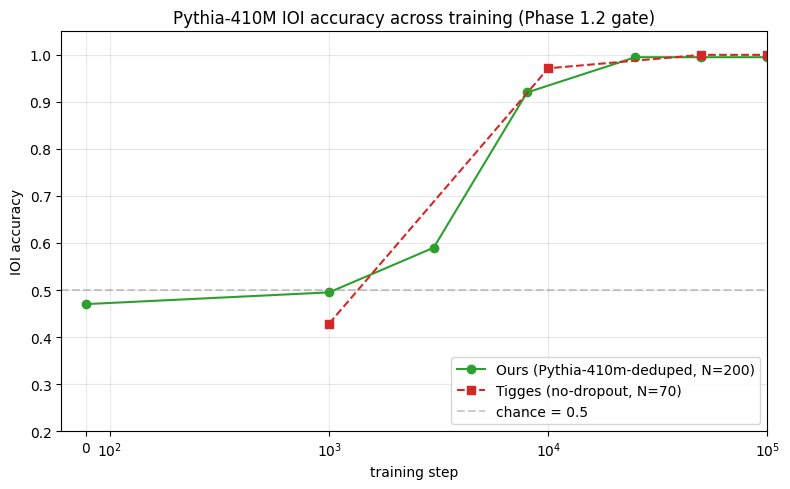

In [4]:
ours_acc = (
    agg[agg['metric'] == 'accuracy']
    .sort_values('step')[['step', 'value']]
    .reset_index(drop=True)
)
tigges_df = pd.DataFrame(
    [(s, v) for s, v in TIGGES_REFERENCE.items()],
    columns=['step', 'value'],
).sort_values('step').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ours_acc['step'], ours_acc['value'],
        marker='o', label='Ours (Pythia-410m-deduped, N=200)',
        color='tab:green')
ax.plot(tigges_df['step'], tigges_df['value'],
        marker='s', linestyle='--', label='Tigges (no-dropout, N=70)',
        color='tab:red')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4,
           label='chance = 0.5')
ax.set_xscale('symlog', linthresh=1000)
ax.set_xlabel('training step')
ax.set_xlim(-100, 10**5)
ax.set_ylabel('IOI accuracy')
ax.set_ylim(0.2, 1.05)
ax.set_title('Pythia-410M IOI accuracy across training (Phase 1.2 gate)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Gate verdict

Per-checkpoint absolute-difference against Tigges at the four directly-shared steps. Gate passes if max-diff is below the locked tolerance (0.10).

In [5]:
shared_steps = [s for s in TIGGES_REFERENCE if s in set(ours_acc['step'])]
ours_at = ours_acc.set_index('step')['value']
rows = []
for s in shared_steps:
    ours_v = float(ours_at[s])
    ref_v = TIGGES_REFERENCE[s]
    diff = abs(ours_v - ref_v)
    rows.append(dict(step=s, ours=ours_v, tigges=ref_v,
                     abs_diff=diff,
                     within_tolerance=diff < GATE_TOLERANCE))
gate_df = pd.DataFrame(rows)
print(gate_df.to_string(index=False))
print()
max_diff = gate_df['abs_diff'].max()
passes = bool(gate_df['within_tolerance'].all())
print(f'Max absolute difference: {max_diff:.4f}')
print(f'Tolerance:               {GATE_TOLERANCE:.4f}')
print(f'GATE: {"PASS" if passes else "FAIL"}')

  step  ours  tigges  abs_diff  within_tolerance
  1000 0.495  0.4286    0.0664              True
 50000 0.995  1.0000    0.0050              True
100000 0.995  1.0000    0.0050              True
143000 0.990  1.0000    0.0100              True

Max absolute difference: 0.0664
Tolerance:               0.1000
GATE: PASS


## Mean logit-diff (supplementary)

Logit-diff = `logit(IO) - logit(S)` at the final position. Tigges reports accuracy as the headline number, but logit-diff is what the circuit-level analysis (path patching, ablations) actually targets, so it's worth tracking too.

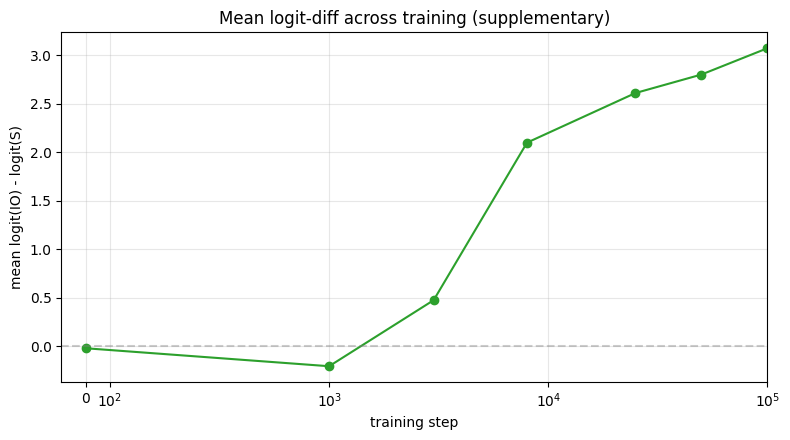

  step     value
     0 -0.019990
  1000 -0.205339
  3000  0.475815
  8000  2.100111
 25000  2.611685
 50000  2.802343
100000  3.073618
143000  2.921241


In [6]:
ours_mld = (
    agg[agg['metric'] == 'mean_logit_diff']
    .sort_values('step')[['step', 'value']]
    .reset_index(drop=True)
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ours_mld['step'], ours_mld['value'], marker='o',
        color='tab:green')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xscale('symlog', linthresh=1000)
ax.set_xlabel('training step')
ax.set_xlim(-100, 10**5)
ax.set_ylabel('mean logit(IO) - logit(S)')
ax.set_title('Mean logit-diff across training (supplementary)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(ours_mld.to_string(index=False))

## Per-prompt logit-diff distribution

Histograms at three exemplar checkpoints (pre-emergence, mid-emergence, post-emergence) to show the shape of the transition. If the bulk of logit-diffs are clustered near zero at early checkpoints and shift right of zero at later checkpoints, the curve isn't driven by a few outlier prompts.

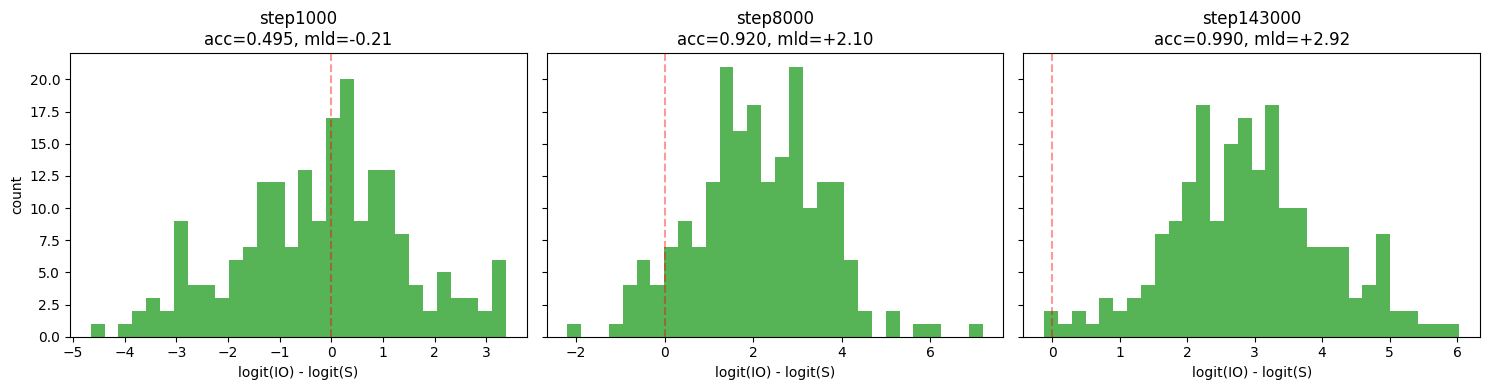

In [7]:
per_prompt = pd.read_parquet(
    REPO / 'data' / 'exploration' / 'tigges_ioi_per_prompt.parquet'
)
exemplar_steps = [1000, 8000, 143000]
fig, axes = plt.subplots(1, len(exemplar_steps), figsize=(15, 4),
                         sharey=True)
for ax, step in zip(axes, exemplar_steps):
    sub = per_prompt[per_prompt['step'] == step]
    ax.hist(sub['logit_diff'], bins=30, color='tab:green', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', alpha=0.4)
    acc = float((sub['logit_diff'] > 0).mean())
    mld = float(sub['logit_diff'].mean())
    ax.set_title(f'step{step}\nacc={acc:.3f}, mld={mld:+.2f}')
    ax.set_xlabel('logit(IO) - logit(S)')
axes[0].set_ylabel('count')
plt.tight_layout()
plt.show()

## ABBA vs BABA breakdown

Per-template accuracy, in case one template lags or leads the other. Wang et al. found IOI heads handle both, but with distinguishable circuit signatures.

  step  ABBA  BABA
     0  0.50  0.44
  1000  0.55  0.44
  3000  0.45  0.73
  8000  0.90  0.94
 25000  0.99  1.00
 50000  1.00  0.99
100000  0.99  1.00
143000  0.99  0.99


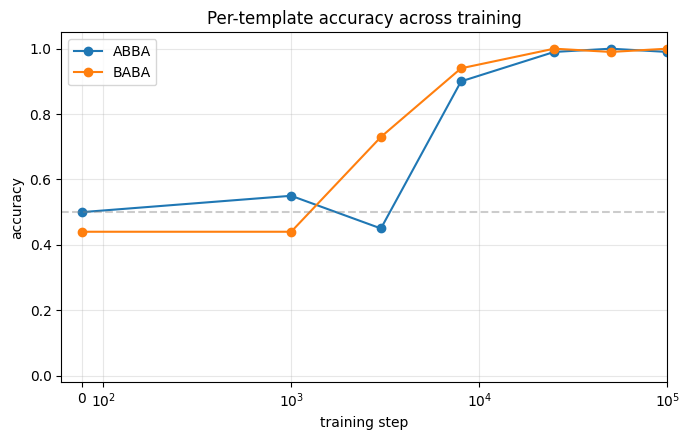

In [8]:
by_kind = (
    per_prompt
    .assign(correct=lambda d: (d['logit_diff'] > 0).astype(int))
    .groupby(['step', 'template_kind'])['correct']
    .mean()
    .unstack()
    .reset_index()
)
print(by_kind.to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 4.5))
for kind, color in [('ABBA', 'tab:blue'), ('BABA', 'tab:orange')]:
    ax.plot(by_kind['step'], by_kind[kind], marker='o', label=kind,
            color=color)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.set_xscale('symlog', linthresh=1000)
ax.set_xlabel('training step')
ax.set_xlim(-100, 10**5)
ax.set_ylabel('accuracy')
ax.set_title('Per-template accuracy across training')
ax.set_ylim(-0.02, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Component DLA at the final checkpoint (post-gate)

Per-(layer, head) direct logit attribution to the IOI logit-diff (`logit(IO) - logit(S)`) at step143000. Each head's output at the final position is projected onto `W_U[:, IO] - W_U[:, S]` and averaged across N=200 prompts. Positive heads push IO above S (Name-Mover-like); negative heads push the other way (Negative-Name-Mover-like).

This is the post-gate deliverable from the locked Q1 design (NOTES.md): IOI accuracy curve as the gate, component-DLA added after the gate passes. Pythia-410M's heads aren't directly labelled in Wang 2023 (Wang focused on GPT-2 small), so this heatmap is the entry point to identifying which Pythia heads play the same circuit roles.

In [9]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
from src.replication.tigges_ioi import component_dla, load_ioi_prompts
from src.utils.pythia_loader import load_pythia

prompts = load_ioi_prompts(REPO / 'data' / 'prompts' / 'ioi_prompts.tsv')
model = load_pythia('410m', step=143000)
dla = component_dla(model, prompts, batch_size=8)
print(f'shape={tuple(dla.shape)}  min={dla.min():.3f}  max={dla.max():.3f}')
del model
import gc, torch
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

/Users/cberg/Documents/Emergence_Research/pythia-motif-emergence/.venv/lib/python3.12/site-packages/transformer_lens/config/HookedTransformerConfig.py:341: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.11.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-410m-deduped into HookedTransformer


shape=(24, 16)  min=-0.221  max=1.337


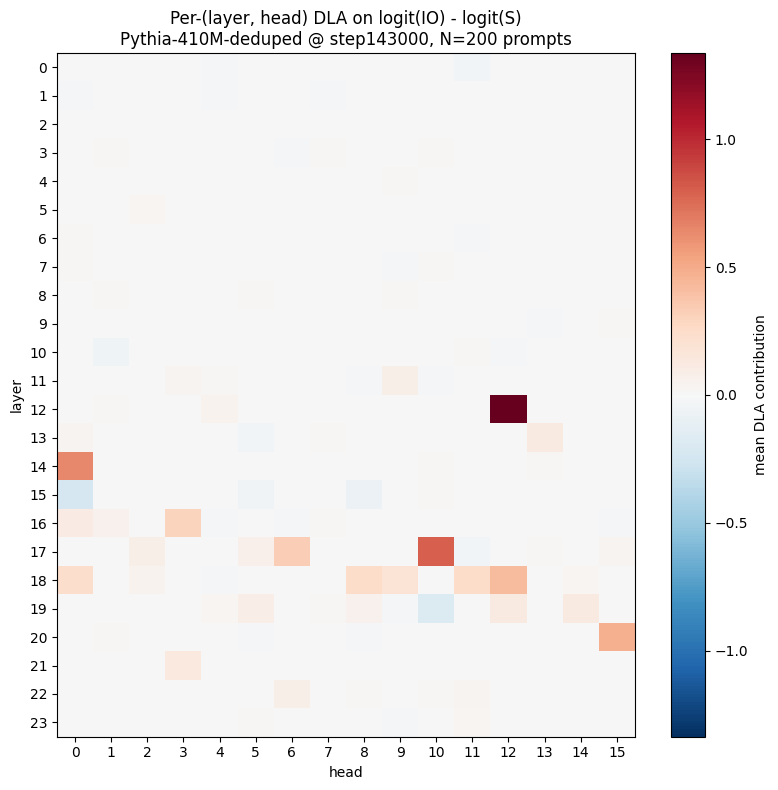

In [10]:
n_layers, n_heads = dla.shape
abs_max = float(dla.abs().max())
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(dla.numpy(), aspect='auto', cmap='RdBu_r',
               vmin=-abs_max, vmax=abs_max)
ax.set_xlabel('head')
ax.set_ylabel('layer')
ax.set_title('Per-(layer, head) DLA on logit(IO) - logit(S)\nPythia-410M-deduped @ step143000, N=200 prompts')
ax.set_xticks(range(n_heads))
ax.set_yticks(range(n_layers))
fig.colorbar(im, ax=ax, label='mean DLA contribution')
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
flat = dla.numpy().flatten()
top_pos = np.argsort(-flat)[:8]
top_neg = np.argsort(flat)[:8]
def lh(idx):
    return idx // n_heads, idx % n_heads
rows = []
for kind, indices in (('positive', top_pos), ('negative', top_neg)):
    for idx in indices:
        L, H = lh(idx)
        rows.append(dict(rank_kind=kind, layer=L, head=H,
                         dla=float(flat[idx])))
top_table = pd.DataFrame(rows)
print('Top 8 positive (Name-Mover-like) and top 8 negative (Negative-Name-Mover-like) heads:')
print(top_table.to_string(index=False))

Top 8 positive (Name-Mover-like) and top 8 negative (Negative-Name-Mover-like) heads:
rank_kind  layer  head       dla
 positive     12    12  1.336928
 positive     17    10  0.800557
 positive     14     0  0.646681
 positive     20    15  0.473092
 positive     18    12  0.426921
 positive     17     6  0.326036
 positive     16     3  0.296523
 positive     18    11  0.249812
 negative     15     0 -0.220935
 negative     19    10 -0.185460
 negative     15     8 -0.082703
 negative     10     1 -0.055039
 negative     15     5 -0.044595
 negative      0    11 -0.036983
 negative     13     5 -0.034626
 negative     17    11 -0.032885


## Verdict

If the gate passed: Phase 1.2 is complete; Phase 1.3 (S-inhibition detector validation) can begin. If the gate failed: per the locked debugging procedure (NOTES.md), check (a) tokenizer version (`-v0` fallback), (b) MPS-vs-CPU numerical drift on a 5-prompt subset, and (c) deduped-vs-no-dropout variant — switch the model template in `pythia_loader.py` if the failure is concentrated near step10000 where Tigges' published value is most distinctive.